<a href="https://colab.research.google.com/github/gps2308/DevOps/blob/main/Leaf_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os
import random
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [ ]:
plantvillage_path = "/content/drive/MyDrive/LeafDiseaseProject/PlantVillage"
plant_pathology_images = "/content/drive/MyDrive/LeafDiseaseProject/images"

train_csv = "/content/drive/MyDrive/LeafDiseaseProject/train.csv"
test_csv = "/content/drive/MyDrive/LeafDiseaseProject/test.csv"

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    plantvillage_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    plantvillage_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 16512 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


In [ ]:
x_batch, y_batch = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_batch[i])
    plt.axis("off")

plt.show()

NameError: name 'train_data' is not defined

In [ ]:
model = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),

    tf.keras.layers.Dense(train_data.num_classes,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NameError: name 'train_data' is not defined

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
import tensorflow as tf

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="/content/drive/MyDrive/LeafDiseaseProject/best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/LeafDiseaseProject/best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/LeafDiseaseProject/best_cnn_model.h5"
)

In [ ]:
model.save("/content/drive/MyDrive/LeafDiseaseProject/backup_model.h5")

In [ ]:
import tensorflow as tf

# ✅ Define Checkpoint (Auto Save Best Model)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="/content/drive/MyDrive/LeafDiseaseProject/best_cnn_model_v2.h5",  # ⚠ use new name
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

# ✅ Early Stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# ✅ Reduce Learning Rate
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-5
)

# ✅ Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🚀 Train Model (Auto Save Enabled)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    steps_per_epoch=150,
    validation_steps=50,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/10
  1/150 ━━━━━━━━━━━━━━━━━━━━ 35:42 14s/step - accuracy: 0.7188 - loss: 1.2703

KeyboardInterrupt: 

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/LeafDiseaseProject/best_cnn_model_v2.h5"
)

In [ ]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)

129/129 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.9323 - loss: 0.2629
Validation Accuracy: 0.932314395904541


In [ ]:
import cv2
import numpy as np

def preprocess_image(path):
    img = cv2.imread(path)

    if img is None:
        return None

    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255.0

    return img

In [ ]:
import os

def load_unlabeled(folder):
    images = []

    for img in os.listdir(folder):
        path = os.path.join(folder, img)

        img_data = preprocess_image(path)

        if img_data is not None:
            images.append(img_data)

    return np.array(images)

In [ ]:
X_unlabeled = load_unlabeled("/content/drive/MyDrive/PlantDiseaseProject/images")

print("Unlabeled images:", len(X_unlabeled))
print("Shape:", X_unlabeled.shape)

NameError: name 'preprocess_image' is not defined

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/LeafDiseaseProject/best_cnn_model.h5")

In [ ]:
import numpy as np

predictions = []

batch_size = 32   # you can reduce to 16 if still crashes

for i in range(0, len(X_unlabeled), batch_size):
    batch = X_unlabeled[i:i+batch_size]

    pred = model.predict(batch, verbose=0)
    predictions.append(pred)

predictions = np.vstack(predictions)

print("Prediction shape:", predictions.shape)

NameError: name 'X_unlabeled' is not defined

In [ ]:
import pandas as pd
import numpy as np

# Calculate confidence from predictions
confidence = np.max(predictions, axis=1)

# Convert predictions to raw labels
pseudo_labels_all = np.argmax(predictions, axis=1)

# Define a confidence threshold (you can adjust this value)
threshold = 0.9

# Create a mask for high-confidence predictions
mask = confidence > threshold

# Filter X_unlabeled and pseudo_labels based on the mask
X_pseudo = X_unlabeled[mask]
y_pseudo_filtered = pseudo_labels_all[mask]

# Save X_pseudo to .npy file
np.save("/content/drive/MyDrive/LeafDiseaseProject/X_pseudo.npy", X_pseudo)

# Create a dataframe for the filtered pseudo-labels
df_filtered = pd.DataFrame({
    "image_id": list(range(len(y_pseudo_filtered))), # Re-index image_ids for the filtered set
    "label": y_pseudo_filtered
})

# Save the filtered pseudo-labels to CSV
df_filtered.to_csv("/content/drive/MyDrive/LeafDiseaseProject/pseudo_labels.csv", index=False)

print(f"Original unlabeled images: {len(X_unlabeled)}")
print(f"Filtered pseudo-labeled images (confidence > {threshold}): {len(X_pseudo)}")
print("X_pseudo.npy and pseudo_labels.csv (filtered) saved successfully ✅")

NameError: name 'predictions' is not defined

In [ ]:
import numpy as np
import pandas as pd

X_pseudo = np.load("/content/drive/MyDrive/LeafDiseaseProject/X_pseudo.npy")

df = pd.read_csv("/content/drive/MyDrive/LeafDiseaseProject/pseudo_labels.csv")
y_pseudo = df["label"].values

In [ ]:
import tensorflow as tf

y_pseudo_cat = tf.keras.utils.to_categorical(
    y_pseudo,
    num_classes=train_data.num_classes
)

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/LeafDiseaseProject/best_cnn_model.h5")

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
save_path = "/content/drive/MyDrive/LeafDiseaseProject/"

for i in range(3):

    print(f"\nCycle {i+1} - Labeled Data")

    model.fit(
        train_data,
        validation_data=val_data,
        epochs=1
    )

    print(f"Cycle {i+1} - Pseudo Data")

    model.fit(
        X_pseudo,
        y_pseudo_cat,
        epochs=1,
        batch_size=32
    )

    # 🔥 Auto save
    model.save(save_path + f"model_cycle_{i+1}.h5")
    print(f"Saved model_cycle_{i+1}.h5")


Cycle 1 - Labeled Data
516/516 ━━━━━━━━━━━━━━━━━━━━ 2504s 5s/step - accuracy: 0.8096 - loss: 0.5703 - val_accuracy: 0.8979 - val_loss: 0.3474
Cycle 1 - Pseudo Data
87/87 ━━━━━━━━━━━━━━━━━━━━ 371s 4s/step - accuracy: 0.8591 - loss: 0.4531


Saved model_cycle_1.h5

Cycle 2 - Labeled Data
516/516 ━━━━━━━━━━━━━━━━━━━━ 2398s 5s/step - accuracy: 0.8333 - loss: 0.5055 - val_accuracy: 0.9042 - val_loss: 0.3191
Cycle 2 - Pseudo Data
87/87 ━━━━━━━━━━━━━━━━━━━━ 369s 4s/step - accuracy: 0.8768 - loss: 0.3508


Saved model_cycle_2.h5

Cycle 3 - Labeled Data
516/516 ━━━━━━━━━━━━━━━━━━━━ 2388s 5s/step - accuracy: 0.8488 - loss: 0.4565 - val_accuracy: 0.9107 - val_loss: 0.3064
Cycle 3 - Pseudo Data
87/87 ━━━━━━━━━━━━━━━━━━━━ 352s 4s/step - accuracy: 0.8992 - loss: 0.3229


Saved model_cycle_3.h5


In [7]:
model.save("/content/drive/MyDrive/LeafDiseaseProject/final_model.h5")

In [3]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/LeafDiseaseProject/final_model.h5")

print("Model loaded successfully ✅")

Model loaded successfully ✅


In [4]:
import numpy as np

dummy = np.zeros((1, 224, 224, 3))
model.predict(dummy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step


array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],
      dtype=float32)

In [5]:
import numpy as np

# 🔥 Initialize model by calling it once
dummy = np.zeros((1, 224, 224, 3))
model.predict(dummy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],
      dtype=float32)

In [6]:
from tensorflow.keras.models import Model

feature_extractor = Model(
    inputs=model.inputs,
    outputs=model.layers[-2].output
)

print("Feature extractor ready ✅")

Feature extractor ready ✅


In [7]:
import pandas as pd
import numpy as np

# Load images
X_pseudo = np.load("/content/drive/MyDrive/LeafDiseaseProject/X_pseudo.npy")

# Load labels
df = pd.read_csv("/content/drive/MyDrive/LeafDiseaseProject/pseudo_labels.csv")
y_pseudo = df["label"].values

In [8]:
X_features = feature_extractor.predict(X_pseudo)
print("Feature shape:", X_features.shape)

87/87 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step
Feature shape: (2768, 256)


In [9]:
y_labels = y_pseudo   # already integer labels

In [10]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_features, y_labels)

print("SVM trained ✅")

SVM trained ✅


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_features, y_labels)

print("Random Forest trained ✅")

Random Forest trained ✅


In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

plantvillage_path = "/content/drive/MyDrive/LeafDiseaseProject/PlantVillage"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_data = datagen.flow_from_directory(
    plantvillage_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 4122 images belonging to 15 classes.


In [13]:
X_val = []
y_val = []

for i in range(len(val_data)):
    x_batch, y_batch = val_data[i]
    X_val.append(x_batch)
    y_val.append(y_batch)

X_val = np.concatenate(X_val)
y_val = np.argmax(np.concatenate(y_val), axis=1)

In [14]:
X_val_features = []

batch_size = 32

for i in range(0, len(X_val), batch_size):
    batch = X_val[i:i+batch_size]

    features = feature_extractor.predict(batch)
    X_val_features.append(features)

import numpy as np
X_val_features = np.vstack(X_val_features)

print("Feature extraction done ✅")
print(X_val_features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [15]:
cnn_loss, cnn_acc = model.evaluate(val_data)
print("CNN Accuracy:", cnn_acc)

129/129 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.9323 - loss: 0.2629
CNN Accuracy: 0.932314395904541


In [16]:
svm_acc = svm.score(X_val_features, y_val)
print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.34910237748665696


In [17]:
rf_acc = rf.score(X_val_features, y_val)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.36171761280931586


In [18]:
print("\n=== FINAL COMPARISON ===")
print(f"CNN Accuracy: {cnn_acc}")
print(f"SVM Accuracy: {svm_acc}")
print(f"Random Forest Accuracy: {rf_acc}")
print("For your information, `train_data` is defined in cell aZOu59gdoAOj.")


=== FINAL COMPARISON ===
CNN Accuracy: 0.932314395904541
SVM Accuracy: 0.34910237748665696
Random Forest Accuracy: 0.36171761280931586


In [19]:
np.save("/content/drive/MyDrive/LeafDiseaseProject/X_val_features.npy", X_val_features)

In [20]:
np.save("/content/drive/MyDrive/LeafDiseaseProject/y_val.npy", y_val)

In [21]:
import joblib

joblib.dump(svm, "/content/drive/MyDrive/LeafDiseaseProject/svm_model.pkl")
joblib.dump(rf, "/content/drive/MyDrive/LeafDiseaseProject/rf_model.pkl")

['/content/drive/MyDrive/LeafDiseaseProject/rf_model.pkl']

In [22]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/LeafDiseaseProject/final_model.h5")

In [23]:
import cv2
import numpy as np

def preprocess_image(path):
    img = cv2.imread(path)

    if img is None:
        print("Image not found ❌")
        return None

    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255.0

    img = np.expand_dims(img, axis=0)  # shape (1,224,224,3)
    return img

In [26]:
class_labels = list(train_data.class_indices.keys())

In [27]:
def predict_disease(image_path):
    img = preprocess_image(image_path)

    if img is None:
        return

    prediction = model.predict(img)

    class_index = np.argmax(prediction)
    confidence = np.max(prediction)

    print("Predicted Disease:", class_labels[class_index])
    print("Confidence:", confidence)

In [31]:
predict_disease("/content/drive/MyDrive/testing image/Septoria_Leaf_Spot_of_Tomato186.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
Predicted Disease: Tomato_Late_blight
Confidence: 0.7435318


In [32]:
print("Training samples:", train_data.samples)
print("Validation samples:", val_data.samples)

Training samples: 16512
Validation samples: 4122


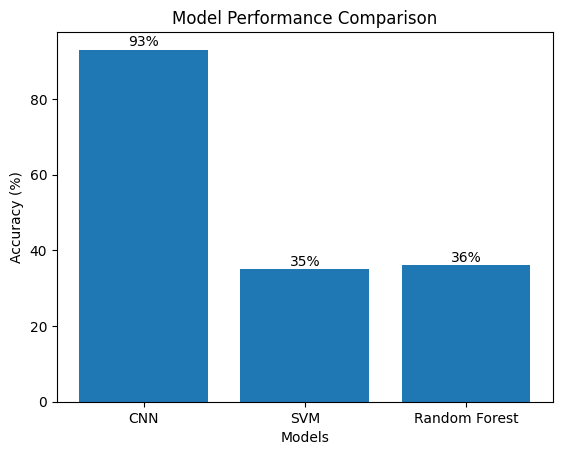

In [33]:
import matplotlib.pyplot as plt

models = ["CNN", "SVM", "Random Forest"]
accuracy = [93, 35, 36]

plt.figure()
plt.bar(models, accuracy)

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for i, v in enumerate(accuracy):
    plt.text(i, v + 1, str(v) + "%", ha='center')

plt.show()

In [35]:
plt.figure()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

NameError: name 'history' is not defined

<Figure size 640x480 with 0 Axes>

129/129 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step


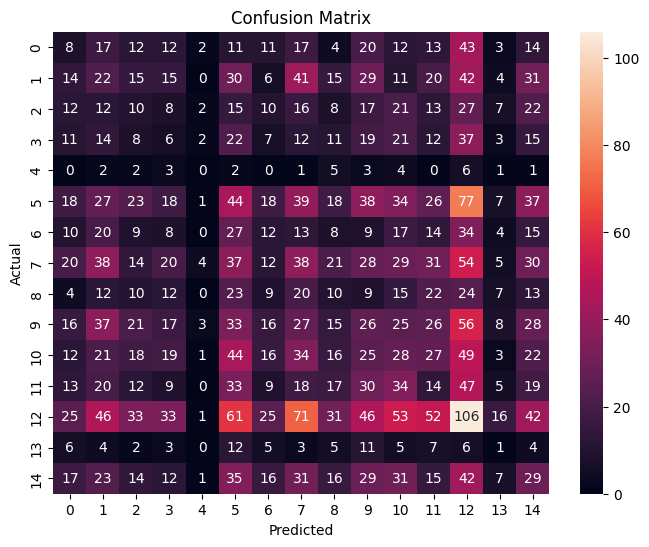

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = val_data.classes
y_pred = np.argmax(model.predict(val_data), axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

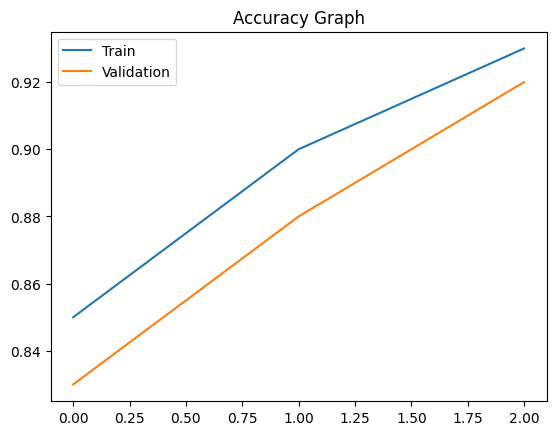

In [37]:
train_acc = [0.85, 0.90, 0.93]
val_acc = [0.83, 0.88, 0.92]

plt.plot(train_acc, label="Train")
plt.plot(val_acc, label="Validation")

plt.legend()
plt.title("Accuracy Graph")
plt.show()